
Ne_R1s(r) =
+40.6917 * exp(-13.9074 r)
+20.0659 * exp(-8.2187 r)
-26.6429 * r^2 * exp(-26.0325 r)
+123.1624 * r * exp(-11.9249 r)
+0.0997 * r * exp(-4.2635 r)
+0.0072 * r * exp(-2.8357 r)
+0.0010 * r * exp(-2.0715 r)

Ne_R2s(r) =
-5.5000 * exp(-13.9074 r)
+19.7683 * exp(-8.2187 r)
-9.9816 * r^2 * exp(-26.0325 r)
-31.5966 * r * exp(-11.9249 r)
-15.1453 * r * exp(-4.2635 r)
-8.1786 * r * exp(-2.8357 r)
-1.7546 * r * exp(-2.0715 r)

Ne_R2p(r) =
+2.7034 * r * exp(-12.3239 r)
+11.7498 * r * exp(-5.6525 r)
+9.4503 * r * exp(-3.5570 r)
+3.3014 * r * exp(-2.2056 r)
+0.6998 * r * exp(-1.4948 r)


/tmp/ipykernel_701/2741710180.py:87: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 1.0000015731418423
Norm 2s = 0.9999998094832664
Norm 2p = 1.0000006916719184
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       8.996529e-02       4.526333e-01       2.735458e-01   
1       0.05       8.995729e-02       4.516824e-01       2.735438e-01   
2       0.10       8.993328e-02       4.488445e-01       2.735265e-01   
3       0.15       8.989328e-02       4.441636e-01       2.734602e-01   
4       0.20       8.983734e-02       4.377112e-01       2.732929e-01   
...      ...                ...                ...                ...   
1996   99.80       7.677476e-08       4.283435e-09       5.061943e-12   
1997   99.85       7.654679e-08       4.270666e-09       5.041828e-12   
1998   99.90       7.631961e-08       4.257942e-09       5.021804e-12   
1999   99.95       7.609321e-08       4.245262e-09       5.001868e-12   
2000  100.00       7.586759e-08       4.232626e-09       4.982022e-12   

        J_total_Ne  
0     2.726472e

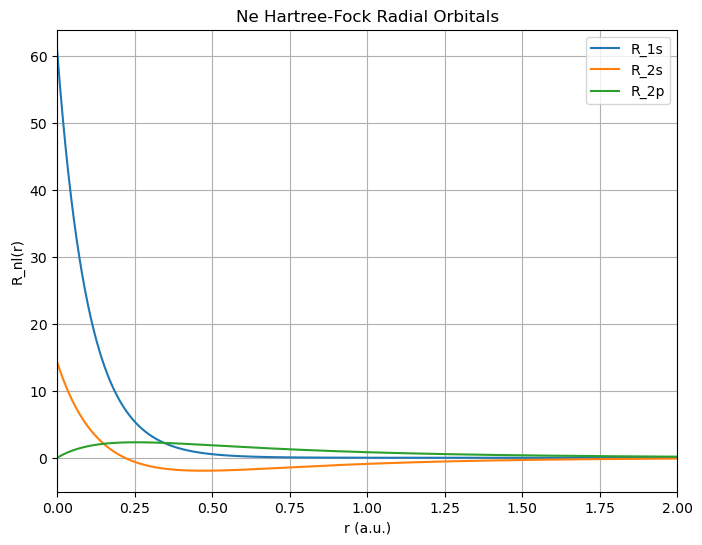

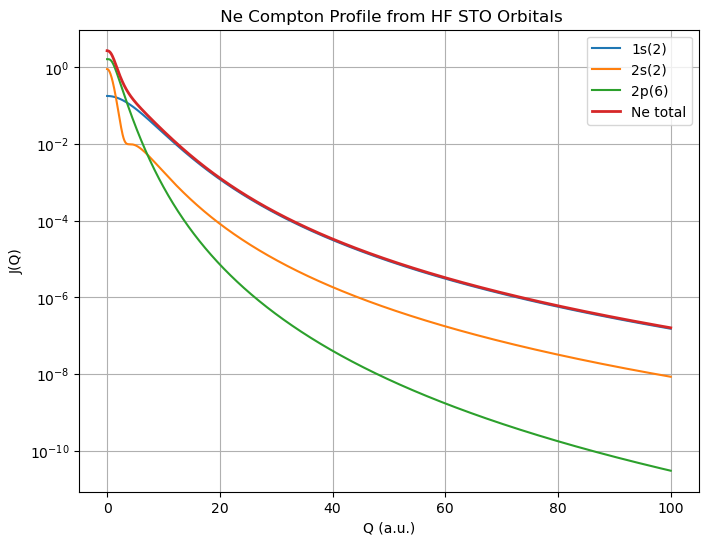

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Neon Hartree-Fock STO data
# Ne: 1s2 2s2 2p6
# Z = 10
# Format: (n_j, Z_j, C_j)
# =====================================================

# -------------------------
# Ne 1s orbital
# -------------------------
neon_1s = [
    (1, 13.9074,  0.392290),
    (1,  8.2187,  0.425817),
    (3, 26.0325, -0.000702),

    (2, 11.9249,  0.217206),
    (2,  4.2635,  0.002300),
    (2,  2.8357,  0.000463),
    (2, 2.0715,  0.000147),
]

# -------------------------
# Ne 2s orbital
# -------------------------
neon_2s = [
    (1, 13.9074, -0.053023),
    (1,  8.2187,  0.419502),
    (3, 26.0325, -0.000263),

    (2, 11.9249, -0.055723),
    (2,  4.2635, -0.349457),
    (2,  2.8357, -0.523070),
    (2, 2.0715,  -0.246038),
]

# -------------------------
# Ne 2p orbital
# -------------------------
neon_2p = [
    (2, 12.3239, 0.004391),
    (2,  5.6525, 0.133955),
    (2,  3.5570, 0.342978),
    (2,  2.2056, 0.395742),
    (2,  1.4948, 0.221831),
]



# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, neon_1s)
R2s = R_nl(r, neon_2s)
R2p = R_nl(r, neon_2p)

print_R_formula(neon_1s, "Ne_R1s")
print_R_formula(neon_2s, "Ne_R2s")
print_R_formula(neon_2p, "Ne_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# Na: 1s2 2s2 2p6 3s1
J_total = 2*J_1s + 2*J_2s + 6*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_Ne": J_total
    })
print(table)
table.to_csv("Ne_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Ne Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")

plt.plot(Q, J_total, label="Ne total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title(" Ne Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()